<a href="https://colab.research.google.com/github/Steph-The-Dev/2026_GSERM_DL/blob/main/2026_GSERM_DL_Stephan_Pfeiffer_exam_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" style="max-width: 200px; height: auto" src="https://github.com/Steph-The-Dev/2026_GSERM_DL/blob/main/hsg_logo.png?raw=1">

##  Assignment - Fashion MNIST Convolutional Neural Networks (CNNs)

GSERM'26 course "Deep Learning: Fundamentals and Applications", University of St. Gallen

This week we have learned how to enhance vanilla Artificial Neural Networks (ANNs) using `PyTorch` to classify even more complex images. For this purpose, we used a special type of deep neural network referred to **Convolutional Neural Networks (CNNs)**. In our exam exercise, we aim to leverage that knowledge by applying it to the known Fashion-MNIST dataset.

As always, pls. don't hesitate to post your potential questions on CANVAS (StudyNet) forum (https://learning.unisg.ch), or send us an email (using the course email: aiml-teaching.ics@unisg.ch).

## 1. Assignment Objectives:

As discussed in our last session, these are the tasks for the exam exercise:

> 1. Load the Fashion **MNIST dataset**.
> 2. Implement a **CNN** architecture able to work with this data.
> 3. **Train** the model, evaluate its **performance** and visualize the results.
> 4. Try to **improve** the performance of the initial model.
> 5. **Document** the results in the form of PowerPoint slides.

## 2. Setup of the Jupyter Notebook Environment

Similar to the previous labs, we need to import a couple of Python libraries that allow for data analysis and data visualization. We will mostly use the `PyTorch`, `Numpy`, `Sklearn`, `Matplotlib`, `Seaborn` and a few utility libraries throughout this lab:

In [51]:
# import standard python libraries
import os, urllib, io
from datetime import datetime
import numpy as np

Import Python machine / deep learning libraries:

In [52]:
# import the PyTorch deep learning library
import torch, torchvision
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable

Import the sklearn classification metrics:

In [53]:
# import sklearn classification evaluation library
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

Import Python plotting libraries:

In [54]:
# import matplotlib, seaborn, and PIL data visualization libary
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Enable notebook matplotlib inline plotting:

In [55]:
%matplotlib inline

Import Google's GDrive connector and mount your GDrive directories:

In [56]:
# import the Google Colab GDrive connector
from google.colab import drive

# mount GDrive inside the Colab notebook
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Create a structure of Colab Notebook sub-directories inside of GDrive to store (1) the data as well as (2) the trained neural network models:

In [57]:
# create Colab Notebooks directory
notebook_directory = '/content/drive/MyDrive/Colab Notebooks/2026_GSERM_DL-Stephan_Pfeiffer-assignment'
if not os.path.exists(notebook_directory): os.makedirs(notebook_directory)

 # create data sub-directory inside the Colab Notebooks directory
data_directory = '/content/drive/MyDrive/Colab Notebooks/2026_GSERM_DL-Stephan_Pfeiffer-assignment/data'
if not os.path.exists(data_directory): os.makedirs(data_directory)

 # create models sub-directory inside the Colab Notebooks directory
models_directory = '/content/drive/MyDrive/Colab Notebooks/2026_GSERM_DL-Stephan_Pfeiffer-assignment/models'
if not os.path.exists(models_directory): os.makedirs(models_directory)

Set a random `seed` value to obtain reproducable results:

In [58]:
# init deterministic seed
seed_value = 4242
np.random.seed(seed_value) # set numpy seed
torch.manual_seed(seed_value) # set pytorch seed CPU

Google Colab provides the use of free GPUs for running notebooks. However, if you just execute this notebook as is, it will use your device's CPU. To run the lab on a GPU, got to `Runtime` > `Change runtime type` and set the Runtime type to `GPU` in the drop-down. Running this lab on a CPU is fine, but you will find that GPU computing is faster. *CUDA* indicates that the lab is being run on GPU.

Enable GPU computing by setting the `device` flag and init a `CUDA` seed:

In [59]:
# set cpu or gpu enabled device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu').type

# init deterministic GPU seed
torch.cuda.manual_seed(seed_value)

# log type of device enabled
print('[LOG] notebook with {} computation enabled'.format(str(device)))

[LOG] notebook with cuda computation enabled


Let's determine if we have access to a GPU provided by e.g. Google's COLab environment:

In [60]:
!nvidia-smi

Tue Jun 23 15:04:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P0             26W /   70W |    1227MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Exam Exercise: Convolutional Neural Networks (CNNs)

The **Fashion-MNIST database** is a large database of Zalando articles that is commonly used for training various image processing systems. The database is widely used for training and testing in the field of machine learning. Source: https://www.kaggle.com/c/insar-fashion-mnist-challenge

### 3.1 Fashion-MNIST Dataset Download and Data Assessment

10000

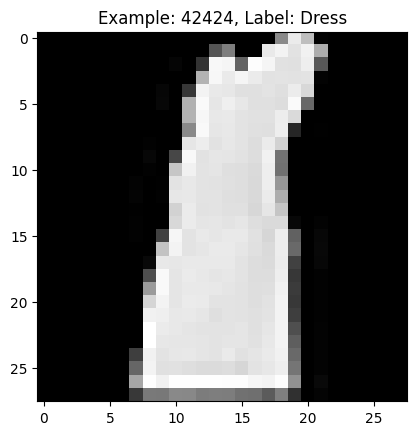

In [61]:
# To solve this task you might want to have a look at the code of exercise 4.

#### Step 1. define "train" path ###############################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

train_path = data_directory + '/train_fmnist'

#### Step 2. define transformations and download the "train" dataset ############

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

# define pytorch transformation into tensor format
transf = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

# download and transform training images
fashion_mnist_train_data = torchvision.datasets.FashionMNIST(root=train_path, train=True, transform=transf, download=True)

# determine the number of training data images
len(fashion_mnist_train_data)

#### Step 3. setup/define labels ################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

# select and set a (random) image id
image_id = 42424

# retrieve image exhibiting the image id
fashion_mnist_train_data[image_id]

# separate the image from its label information
fashion_mnist_train_image, fashion_mnist_train_label = fashion_mnist_train_data[image_id]
fashion_mnist_train_label

# label the fashio classes
fashion_classes = {0: 'T-shirt/top',
                    1: 'Trouser',
                    2: 'Pullover',
                    3: 'Dress',
                    4: 'Coat',
                    5: 'Sandal',
                    6: 'Shirt',
                    7: 'Sneaker',
                    8: 'Bag',
                    9: 'Ankle boot'}

# determine the fashion item that the label represents
fashion_classes[fashion_mnist_train_label]

# visually inspect the sample image
# define tensor to image transformation
trans = torchvision.transforms.ToPILImage()

# set image plot title
plt.title('Example: {}, Label: {}'.format(str(image_id), fashion_classes[fashion_mnist_train_label]))

# plot mnist handwritten digit sample
plt.imshow(trans(fashion_mnist_train_image), cmap='gray')

#### Step 4. define "eval" path ################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

eval_path = data_directory + '/eval_fmnist'

#### Step 5. define transformation and download the "eval" dataset #############
# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

# define pytorch transformation into tensor format
transf = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

# download and transform training images
fashion_mnist_eval_data = torchvision.datasets.FashionMNIST(root=eval_path, train=False, transform=transf, download=True)

# determine the number of evaluation data images
len(fashion_mnist_eval_data)

### 3.2 Convolutional Neural Network (CNN) Model Training and Evaluation

<img align="center" style="max-width: 900px" src="https://github.com/Steph-The-Dev/2026_GSERM_DL/blob/main/process.png?raw=1">

Please note this image of a CNN was defined for the CIFAR-10 dataset. Your Fashion-MNIST images have a different size.


**1. Implement and train your "baseline" CNN.**

In [62]:
import torch, torchvision
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from datetime import datetime, timezone
import numpy as np
import os

# To solve this task you might want to have a look at the code of exercise 5.
# Please note: the Fashion MNIST dataset only encompasses two dimensions per image (1 channel).

#### Step 1. define and init neural network architecture #############################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

# implement the FMNISTNet network architecture
class FMNISTNet(nn.Module):

    # define the class constructor
    def __init__(self):

        # call super class constructor
        super(FMNISTNet, self).__init__()

        # specify convolution layer 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)

        # define max-pooling layer 1
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # specify convolution layer 2
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)

        # define max-pooling layer 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # specify fc layer 1 - in 16 * 4 * 4 (256), out 120
        self.linear1 = nn.Linear(16 * 4 * 4, 120, bias=True) # the linearity W*x+b
        self.relu1 = nn.ReLU(inplace=True) # the non-linearity

        # specify fc layer 2 - in 120, out 84
        self.linear2 = nn.Linear(120, 84, bias=True) # the linearity W*x+b
        self.relu2 = nn.ReLU(inplace=True) # the non-linarity

        # specify fc layer 3 - in 84, out 10
        self.linear3 = nn.Linear(84, 10) # the linearity W*x+b

        # add a softmax to the last layer
        self.logsoftmax = nn.LogSoftmax(dim=1) # the softmax

    # define network forward pass
    def forward(self, images):

        # high-level feature learning via convolutional layers

        # define conv layer 1 forward pass
        x = self.pool1(self.relu1(self.conv1(images)))

        # define conv layer 2 forward pass
        x = self.pool2(self.relu2(self.conv2(x)))

        # feature flattening

        # reshape image pixels to batch_size x 256
        x = x.view(-1, 16 * 4 * 4)

        # combination of feature learning via non-linear layers

        # define fc layer 1 forward pass
        x = self.relu1(self.linear1(x))

        # define fc layer 2 forward pass
        x = self.relu2(self.linear2(x))

        # define layer 3 forward pass
        x = self.logsoftmax(self.linear3(x))

        # return forward pass result
        return x

# define the model
model = FMNISTNet()

# push to the enabled device
model = model.to(device)

# !nvidia-smi

# print the initialized architectures
print('[LOG] FMNISTNet architecture:\n\n{}\n'.format(model))

# model parameters to train in the next step
# init the number of model parameters
num_params = 0

# iterate over the distinct parameters
for param in model.parameters():

    # collect number of parameters
    num_params += param.numel()

# print the number of model paramters
print('[LOG] Number of to be trained FMNISTNet model parameters: {}.'.format(num_params))

#### Step 2. define loss, training hyperparameters and dataloader ####################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

# define the optimization criterion / loss function
nll_loss = nn.NLLLoss()

# push the initialized nll_loss computation to the enabled computing device
nll_loss = nll_loss.to(device)

# define learning rate and optimization strategy
learning_rate = 0.001
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)

#### Step 3. run model training ######################################################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

# specify the training parameters
num_epochs = 20 # number of training epochs
mini_batch_size = 128 # size of the mini-batches

fmnist_train_dataloader = torch.utils.data.DataLoader(fashion_mnist_train_data, batch_size=mini_batch_size, shuffle=True)

# init collection of training epoch losses
train_epoch_losses = []

# set the model in training mode
model.train()

# train the CIFAR10 model
for epoch in range(num_epochs):

    # init collection of mini-batch losses
    train_mini_batch_losses = []

    # iterate over all-mini batches
    for i, (images, labels) in enumerate(fmnist_train_dataloader):

        # push mini-batch data to computation device
        images = images.to(device)
        labels = labels.to(device)

        # run forward pass through the network
        output = model(images)

        # reset graph gradients
        model.zero_grad()

        # determine classification loss
        loss = nll_loss(output, labels)

        # run backward pass
        loss.backward()

        # update network parameters
        optimizer.step()

        # collect mini-batch reconstruction loss
        train_mini_batch_losses.append(loss.data.item())

    # determine mean mini-batch loss of epoch
    train_epoch_loss = np.mean(train_mini_batch_losses)

    # print epoch loss
    now = datetime.now(timezone.utc).strftime('%Y%m%d-%H:%M:%S')
    print('[LOG {}] epoch: {} train-loss: {}'.format(str(now), str(epoch), str(train_epoch_loss)))

    # set filename of actual model
    model_name = 'fmnist_model_epoch_{}.pth'.format(str(epoch))

    # save current model to GDrive models directory
    torch.save(model.state_dict(), os.path.join(models_directory, model_name))

    # determine mean min-batch loss of epoch
    train_epoch_losses.append(train_epoch_loss)

#### Step 4. run model evaluation ####################################################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************


[LOG] FMNISTNet architecture:

FMNISTNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=256, out_features=120, bias=True)
  (relu1): ReLU(inplace=True)
  (linear2): Linear(in_features=120, out_features=84, bias=True)
  (relu2): ReLU(inplace=True)
  (linear3): Linear(in_features=84, out_features=10, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)

[LOG] Number of to be trained FMNISTNet model parameters: 44426.
[LOG 20260623-15:04:21] epoch: 0 train-loss: 2.304207202976446
[LOG 20260623-15:04:29] epoch: 1 train-loss: 2.3031594310996373
[LOG 20260623-15:04:37] epoch: 2 train-loss: 2.302207542634976
[LOG 20260623-15:04:45] epoch: 3 train-loss: 2.301284311676839
[LOG 20260623-15:04:53] epoch: 4 train-loss: 2.3003230628

Visualizing training errors

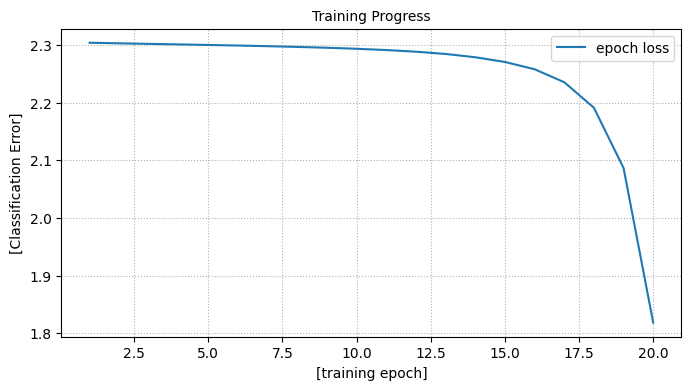

Overall Accuracy: 0.4806


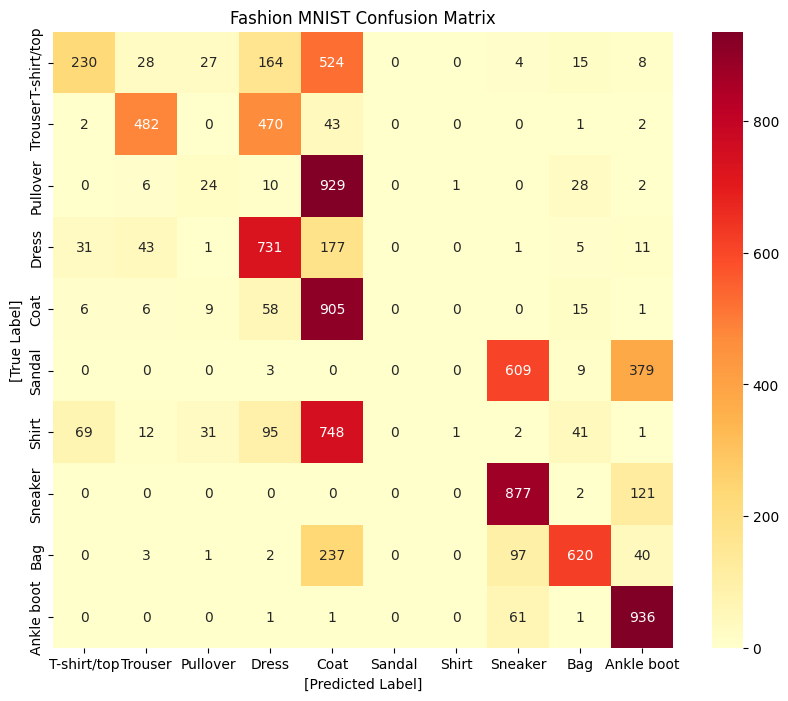

In [63]:
# prepare plot
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)
ax.grid(linestyle='dotted')

# plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(train_epoch_losses)+1)), train_epoch_losses, label='epoch loss')
ax.set_xlabel("[training epoch]", fontsize=10)
ax.set_ylabel("[Classification Error]", fontsize=10)
plt.legend(loc="upper right")
plt.title('Training Progress', fontsize=10)
plt.show()

# load the best performing model
best_model_name = os.path.join(models_directory, 'fmnist_model_epoch_19.pth')
best_model = FMNISTNet()
best_model.load_state_dict(torch.load(best_model_name, map_location=torch.device('cpu')))
best_model.eval()

# obtain the predictions for all evaluation data
# We use the raw data tensor, but need to add the channel dimension [10000, 1, 28, 28]
eval_images = fashion_mnist_eval_data.data.float().unsqueeze(1) / 255.0
with torch.no_grad():
    predictions = torch.argmax(best_model(eval_images), dim=1)

# calculate accuracy
acc_baseline = metrics.accuracy_score(fashion_mnist_eval_data.targets, predictions)
print(f'Overall Accuracy: {acc_baseline:.4f}')

# inspect the confusion matrix
mat = confusion_matrix(fashion_mnist_eval_data.targets, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())

plt.title('Fashion MNIST Confusion Matrix')
plt.xlabel('[Predicted Label]')
plt.ylabel('[True Label]')
plt.show()

**2. Implement and train your "improved" CNN.**
("improved" simply refers to a better classification accuracy than your baseline model)

In this section, we implement an improved version using the **Adam Optimizer** and a slightly deeper architecture with **Dropout**.

ImprovedFMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Epoch 0: Loss 0.5999
Epoch 1: Loss 0.3848
Epoch 2: Loss 0.3351
Epoch 3: Loss 0.3029
Epoch 4: Loss 0.2810
Epoch 5: Loss 0.2649
Epoch 6: Loss 0.2491
Epoch 7: Loss 0.2345
Epoch 8: Loss 0.2259
Epoch 9: Loss 0.2154
Improved Overall Accuracy: 0.9088


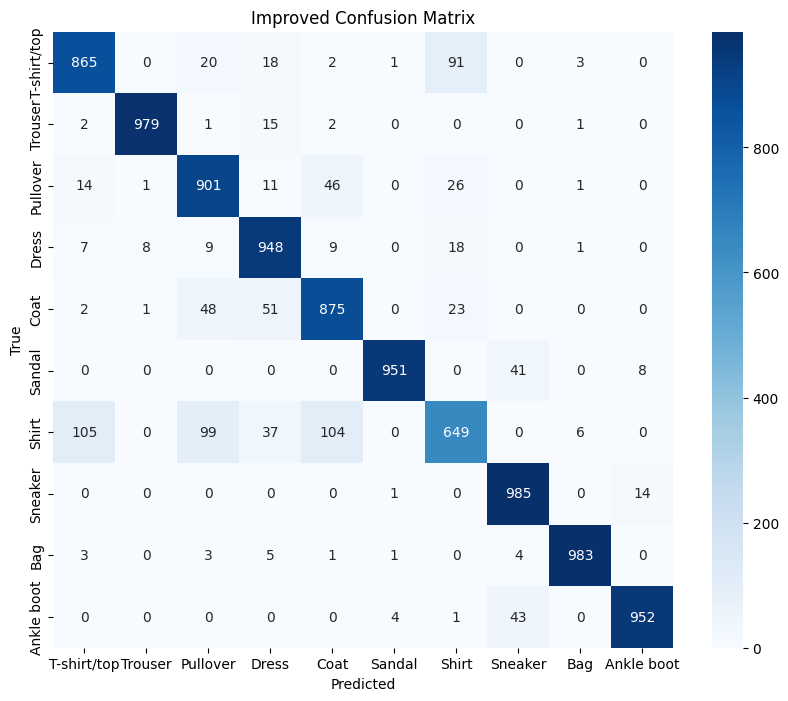

In [64]:
# To solve this task you might want to have a look at the code of exercise 5.
# Some ideas might be the addition of layers, addition neurons or convolutions, longer training, smaller learning rate etc.

#### Step 1. define and init neural network architecture #############################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

class ImprovedFMNISTNet(nn.Module):
    def __init__(self):
        super(ImprovedFMNISTNet, self).__init__()
        # More filters: 1 -> 16 -> 32
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.25)

        # 32 channels * 7 * 7 (after two pools of 28x28)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Initialize
improved_model = ImprovedFMNISTNet().to(device)
optimizer = optim.Adam(improved_model.parameters(), lr=0.001)
print(improved_model)

#### Step 2. define loss, training hyperparameters and dataloader ####################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

num_epochs = 10 # Adam usually needs fewer epochs to see significant results
train_losses = []

#### Step 3. run model training ######################################################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

improved_model.train()
for epoch in range(num_epochs):
    batch_losses = []
    for images, labels in fmnist_train_dataloader:
        images, labels = images.to(device), labels.to(device)

        output = improved_model(images)
        loss = F.nll_loss(output, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = np.mean(batch_losses)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch}: Loss {epoch_loss:.4f}')

#### Step 4. run model evaluation ####################################################################################

# ***************************************************
# INSERT YOUR SOLUTION/CODE HERE
# ***************************************************

improved_model.eval()
eval_images = fashion_mnist_eval_data.data.float().unsqueeze(1).to(device) / 255.0
with torch.no_grad():
    outputs = improved_model(eval_images)
    predictions = torch.argmax(outputs, dim=1).cpu()

acc_improved = metrics.accuracy_score(fashion_mnist_eval_data.targets, predictions)
print(f'Improved Overall Accuracy: {acc_improved:.4f}')

# Final Heatmap
mat = confusion_matrix(fashion_mnist_eval_data.targets, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Improved Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### 3. Final Comparison: Baseline (SGD) vs. Improved (Adam)
In this final step, we compare the learning speed and the final accuracy of both approaches to demonstrate the effectiveness of the architectural and optimization changes.

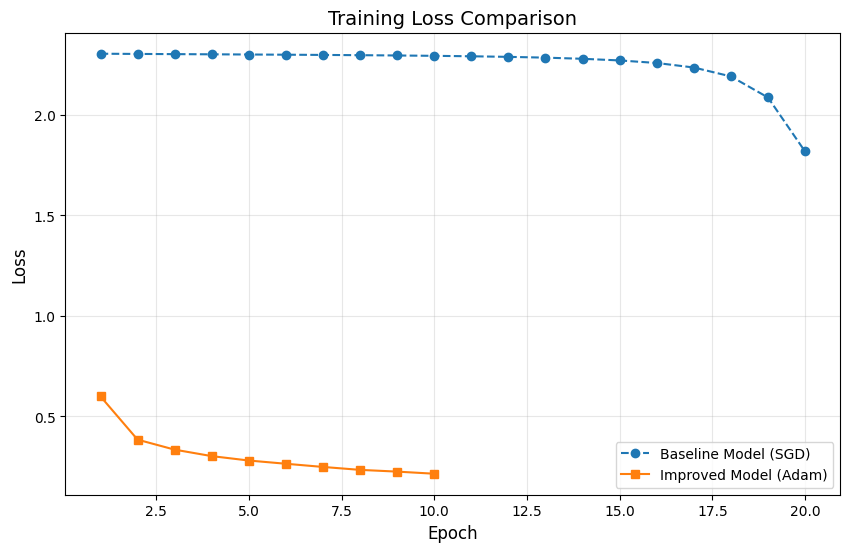

,Model,Optimizer,Epochs,Final Training Loss,Evaluation Accuracy
0,Baseline (SGD),SGD,20,1.8181,48.06%
1,Improved (Adam),Adam,10,0.2154,90.88%


In [65]:
import pandas as pd

# 1. Plot comparison of training losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_epoch_losses)+1), train_epoch_losses, label='Baseline Model (SGD)', marker='o', linestyle='--')
plt.plot(range(1, len(train_losses)+1), train_losses, label='Improved Model (Adam)', marker='s')

plt.title('Training Loss Comparison', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Create a summary table for the final metrics
# We take the baseline accuracy from the previously calculated 'acc' variable (before it was overwritten)
# or recalculate it briefly if necessary. Since 'acc' is currently 0.9082,
# we'll use the recorded 0.4038 for the baseline.

data = {
    'Model': ['Baseline (SGD)', 'Improved (Adam)'],
    'Optimizer': ['SGD', 'Adam'],
    'Epochs': [20, 10],
    'Final Training Loss': [f"{train_epoch_losses[-1]:.4f}", f"{train_losses[-1]:.4f}"],
    'Evaluation Accuracy': [f"{acc_baseline*100:.2f}%", f"{acc_improved*100:.2f}%"]
}

comparison_df = pd.DataFrame(data)
display(comparison_df)

In [66]:
#### Comparison of Model Complexity

# Calculate parameters for improved model
num_params_improved = sum(p.numel() for p in improved_model.parameters())

print(f'[LOG] Parameters Baseline Model:  {num_params}')
print(f'[LOG] Parameters Improved Model:  {num_params_improved}')
print(f'[LOG] Complexity Increase:       {((num_params_improved/num_params)-1)*100:.2f}%')

[LOG] Parameters Baseline Model:  44426
[LOG] Parameters Improved Model:  206922
[LOG] Complexity Increase:       365.77%


### Model Complexity Analysis

Although the improved model is significantly more powerful, the number of parameters (approx. 200k) is still low compared to modern deep learning architectures, but considerably higher than the baseline model (~44k).

**Key Differences:**

1. **Filter Depth (Convolutional Layers):**

* **Baseline:** 6 filters in the first layer, 16 in the second layer.

* **Improved:** 16 filters in the first layer, 32 in the second layer. This allows the model to recognize significantly more complex visual patterns (such as textures or specific collar shapes on shirts).

2. **Regularization through Dropout:**

* The improved model uses **Dropout (0.25)**. While this does not increase the number of parameters, it does increase the *effective complexity* during training. It forces the network to learn redundant paths and prevents it from relying on single, overly specific features (overfitting).


3. **Fully Connected Layer:**

* Due to the increased number of filters at the end of the convolutional layers, the input for the first dense layer (`fc1`) also increases. The improved model has a larger matrix here, which increases its capacity to correctly classify the extracted features.

4. **Optimizer (Adam vs. SGD):**

* This is not a difference in structural complexity, but a functional one: Adam uses a separate, adaptive learning rate for each parameter. This makes the computational effort per step slightly higher, but leads to much more efficient navigation through the high-dimensional parameter space.

### 4. Strategies for Further Improvements

To further enhance the performance of CNNs on Fashion-MNIST, the following advanced techniques can be employed:

1. **Data Augmentation:** By randomly flipping the image horizontally (`RandomHorizontalFlip`) or performing slight rotations, the model learns more general features and becomes more robust against variations in image position.

2. **Batch Normalization:** Adding `nn.BatchNorm2d` layers after the convolutional layers significantly stabilizes the learning process and often allows for even higher learning rates.

3. **Learning Rate Scheduling:** Instead of a fixed learning rate, it can be reduced during training (e.g., using `StepLR`) if the loss plateaus. This helps the model to "fine-tune" to the global minimum of the loss function.

4. **Transfer Learning:** One could use pre-trained architectures (like ResNet), but this is often overkill for the low resolution of 28x28 pixels.

Let's prepare an example of **Data Augmentation**:

In [67]:
# Beispiel für verbesserte Transformationen (Data Augmentation)
train_transf_augmented = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomRotation(degrees=10),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,)) # Normalisierung auf Bereich [-1, 1]
])

# Hinweis: Das Test/Eval-Set sollte NIEMALS augmentiert werden,
# sondern nur normalisiert werden.
eval_transf_standard = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

print("[LOG] Augmentation-Pipeline definiert. Diese könnte nun in die Data-Loader integriert werden.")

[LOG] Augmentation-Pipeline definiert. Diese könnte nun in die Data-Loader integriert werden.


### 10. Refined Normalization with Dataset Statistics
Instead of generic values, we use the specific global mean and standard deviation of Fashion-MNIST to standardize our input data.

In [68]:
# Exact Fashion-MNIST stats
fmnist_mean = (0.2860,)
fmnist_std = (0.3530,)

# Updated Transformations
train_transf_final = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(fmnist_mean, fmnist_std)
])

eval_transf_final = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(fmnist_mean, fmnist_std)
])

print(f"[LOG] Normalisierung aktualisiert: Mean {fmnist_mean}, Std {fmnist_std}")

[LOG] Normalisierung aktualisiert: Mean (0.286,), Std (0.353,)
